In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Cleaned_Applications.csv")


In [3]:
print(df.head())


           application                                            program  \
0  IITJMETBT1092410156  IIT Jodhpur - School of Management and Entrepr...   
1  IITJMETBT1092410288  IIT Jodhpur - School of Management and Entrepr...   
2  IITJMETBT1122429396  IIT Jodhpur - School of Management and Entrepr...   
3   IITJMETBT108249920  IIT Jodhpur - School of Management and Entrepr...   
4   IITJMETBT108249881  IIT Jodhpur - School of Management and Entrepr...   

   batch                  name                         email       phone  \
0      1  Neelam Venkata Akash  neelamvenkataakash@gmail.com  8770175185   
1      1       ChiragDakshikar     chiragdakshikar@gmail.com  8657195171   
2      1          ValmikJaware        valmikjaware@gmail.com  9116197117   
3      1         VaibhavMishra   mishravaibhav2233@gmail.com  6106811506   
4      1         KanishkaUtsav       kanishkautsav@gmail.com  8574006311   

  current_status completed_step   submission_date general_manager  ...  \
0     

In [4]:
print(df.info())

print(df.describe())

print(df.select_dtypes(include='object').describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   application            216 non-null    object 
 1   program                216 non-null    object 
 2   batch                  216 non-null    int64  
 3   name                   216 non-null    object 
 4   email                  194 non-null    object 
 5   phone                  216 non-null    int64  
 6   current_status         216 non-null    object 
 7   completed_step         216 non-null    object 
 8   submission_date        216 non-null    object 
 9   general_manager        216 non-null    object 
 10  source                 216 non-null    object 
 11  date_of_birth          216 non-null    object 
 12  current_country        216 non-null    object 
 13  current_state          216 non-null    object 
 14  current_city           216 non-null    object 
 15  curren

In [7]:
print(df['current_status'].value_counts())




current_status
Approved     141
No Status     57
Reject        17
Resend         1
Name: count, dtype: int64


In [11]:
print(df['program'].value_counts())

print(df['current_status'].value_counts())

print(df['completed_step'].value_counts())

print(df['source'].value_counts())

print(df['general_manager'].value_counts())


program
IIT Jodhpur - School of Management and Entrepreneurship - MBA Technology    216
Name: count, dtype: int64
current_status
Approved     141
No Status     57
Reject        17
Resend         1
Name: count, dtype: int64
completed_step
Step 3    216
Name: count, dtype: int64
source
-    216
Name: count, dtype: int64
general_manager
Akshit Mittal    216
Name: count, dtype: int64


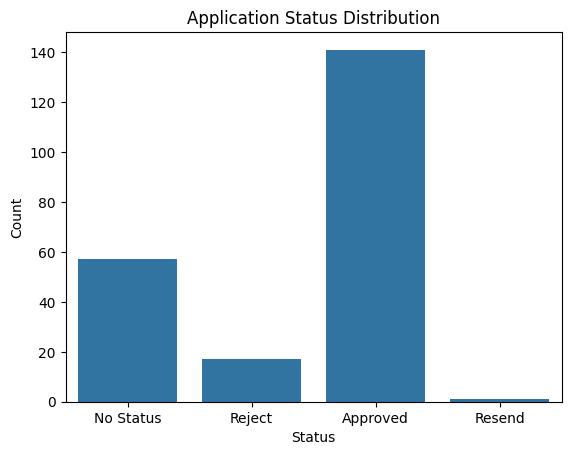

In [9]:
sns.countplot(data=df, x='current_status')
plt.title("Application Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


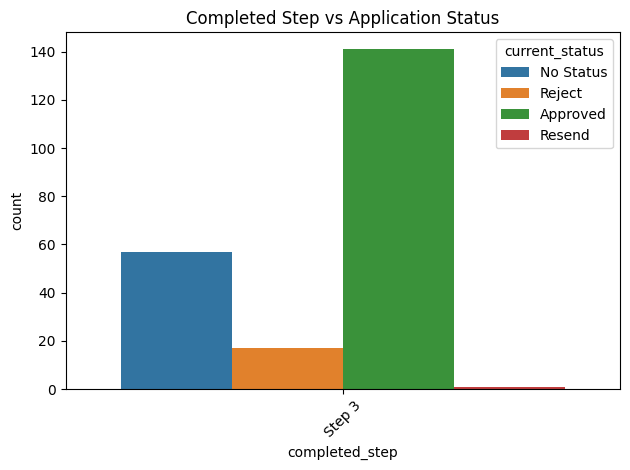

In [12]:
#DATA VISUALIZATION
sns.countplot(data=df, x='completed_step', hue='current_status', order=df['completed_step'].value_counts().index)
plt.title("Completed Step vs Application Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


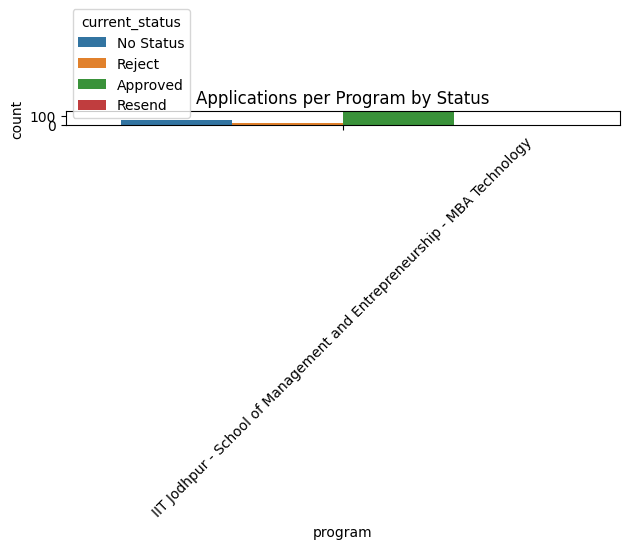

In [13]:
sns.countplot(data=df, x='program', hue='current_status')
plt.title("Applications per Program by Status")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


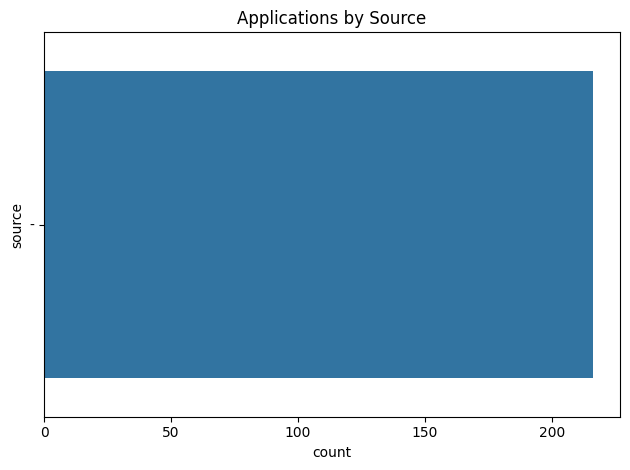

In [14]:
sns.countplot(data=df, y='source', order=df['source'].value_counts().index)
plt.title("Applications by Source")
plt.tight_layout()
plt.show()


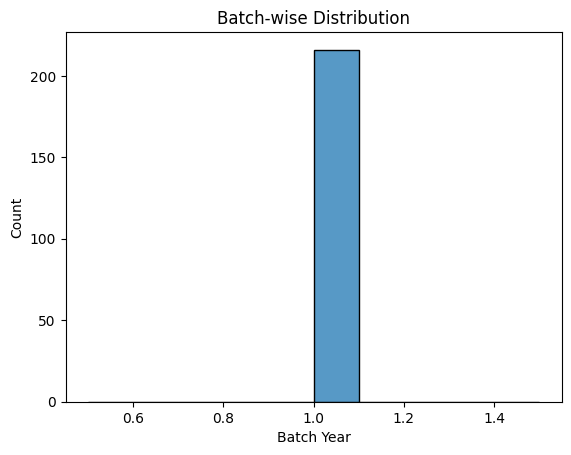

In [15]:
sns.histplot(df['batch'], bins=10, kde=False)
plt.title("Batch-wise Distribution")
plt.xlabel("Batch Year")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_22372\3660967232.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')


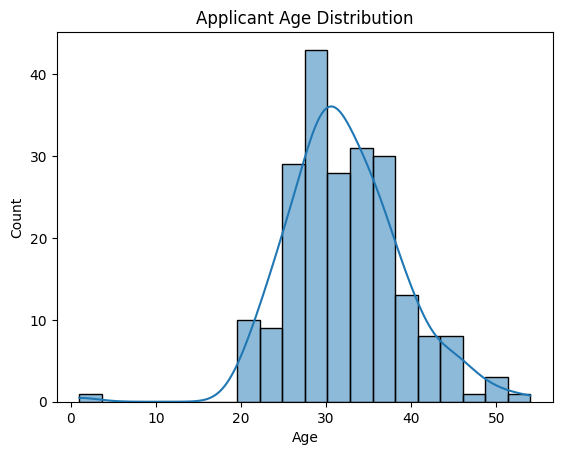

In [16]:
# Convert date columns
df['submission_date'] = pd.to_datetime(df['submission_date'], errors='coerce')
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

# Age calculation
df['age'] = pd.to_datetime("today").year - df['date_of_birth'].dt.year

# Plot age distribution
sns.histplot(df['age'], kde=True)
plt.title("Applicant Age Distribution")
plt.xlabel("Age")
plt.show()


current_state
Karnataka        28
Maharashtra      27
Rajasthan        19
Uttar Pradesh    18
Delhi            17
Haryana          17
Tamil Nadu       14
Telangana        11
West Bengal      10
Orissa            9
Name: count, dtype: int64


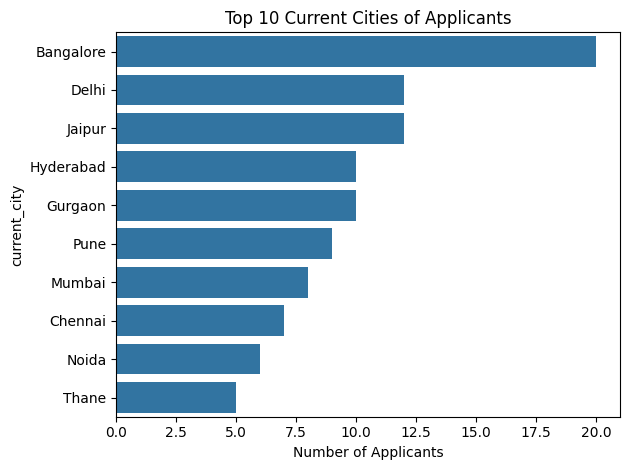

In [17]:
# Top current states
print(df['current_state'].value_counts().head(10))

# Applications by current city (Top 10)
top_cities = df['current_city'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Current Cities of Applicants")
plt.xlabel("Number of Applicants")
plt.tight_layout()
plt.show()


In [18]:
df.to_csv("processed_application_data.csv", index=False)
